In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [2]:
end_date = datetime.now()
start_date = end_date - timedelta(days=365*5)

In [3]:
ticker_1 = input("Inserisci il ticker del primo titolo: ")
ticker_2 = input("Inserisci il ticker del secondo titolo: ")

Inserisci il ticker del primo titolo:  NVDA
Inserisci il ticker del secondo titolo:  WMT


In [5]:
data1 = yf.download(ticker_1,start=start_date,end=end_date,interval='1mo')
data2 = yf.download(ticker_2,start=start_date,end=end_date,interval='1mo')

print(data1.head())
print(data2.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open       Volume
Ticker           NVDA       NVDA       NVDA       NVDA         NVDA
Date                                                               
2020-09-01  13.486050  14.678370  11.665799  13.435715  15856552000
2020-10-01  12.496559  14.305639  12.263258  13.716903   8022356000
2020-11-01  13.361469  14.647616  12.357976  12.619941   7594820000
2020-12-01  13.016005  13.690234  12.725126  13.451949   5120996000
2021-01-01  12.954775  13.961557  12.552112  13.068967   6154172000
Price           Close       High        Low       Open     Volume
Ticker            WMT        WMT        WMT        WMT        WMT
Date                                                             
2020-09-01  43.604229  47.163377  41.996070  44.006270  805971600
2020-10-01  43.242706  45.689232  42.812618  43.881608  386985000
2020-11-01  47.618389  47.808499  43.329961  43.816149  413800500
2020-12-01  44.925663  47.889543  44.349095  47.870843  5111

In [6]:
returns_df = pd.DataFrame()
returns_df[ticker_1] = data1['Close'].pct_change()
returns_df[ticker_2] = data2['Close'].pct_change()
returns_df = returns_df.dropna()

print(returns_df.head())

                NVDA       WMT
Date                          
2020-10-01 -0.073371 -0.008291
2020-11-01  0.069212  0.101189
2020-12-01 -0.025855 -0.056548
2021-01-01 -0.004704 -0.021828
2021-02-01  0.055794 -0.075237


In [7]:
statistics_df = pd.DataFrame({
    "Expected Returns": returns_df.mean(),
    "Variance": returns_df.var(),
    "Standard Deviation": returns_df.std()
})

print(statistics_df)

      Expected Returns  Variance  Standard Deviation
NVDA          0.055988  0.021932            0.148093
WMT           0.015716  0.003376            0.058103


In [8]:
corr_matrix = returns_df.corr()
print(corr_matrix)

          NVDA       WMT
NVDA  1.000000  0.270612
WMT   0.270612  1.000000


In [9]:
cov_matrix = returns_df.cov()
print(cov_matrix)

          NVDA       WMT
NVDA  0.021932  0.002329
WMT   0.002329  0.003376


In [10]:
ones = np.ones((cov_matrix.shape[0], 1))  
cov_inv = np.linalg.inv(cov_matrix.values)
u = statistics_df["Expected Returns"]

a11 = ones.T @ cov_inv @ ones
a11 = a11.item()
a12 = ones.T @ cov_inv @ u
a12 = a12.item()
a22 = u.T @ cov_inv @ u

In [11]:
sigma_min = np.sqrt(1/a11)
mu_min = a12/a11

print(sigma_min)
print(mu_min)

0.057643666679511193
0.017758376829622495


In [12]:
# Crea i sigma_star
sigma_star = np.arange(sigma_min, 0.2, 0.0005)

rad = (a11 * sigma_star**2 - 1) * (a11 * a22 - a12**2)

# Filtra solo i valori con rad >= 0
mask = rad >= 0

sigma_valid = sigma_star[mask]
rad_valid = rad[mask]

mu_ef = (1/a11) * (a12 + np.sqrt(rad_valid))
mu_inf = (1/a11) * (a12 - np.sqrt(rad_valid))

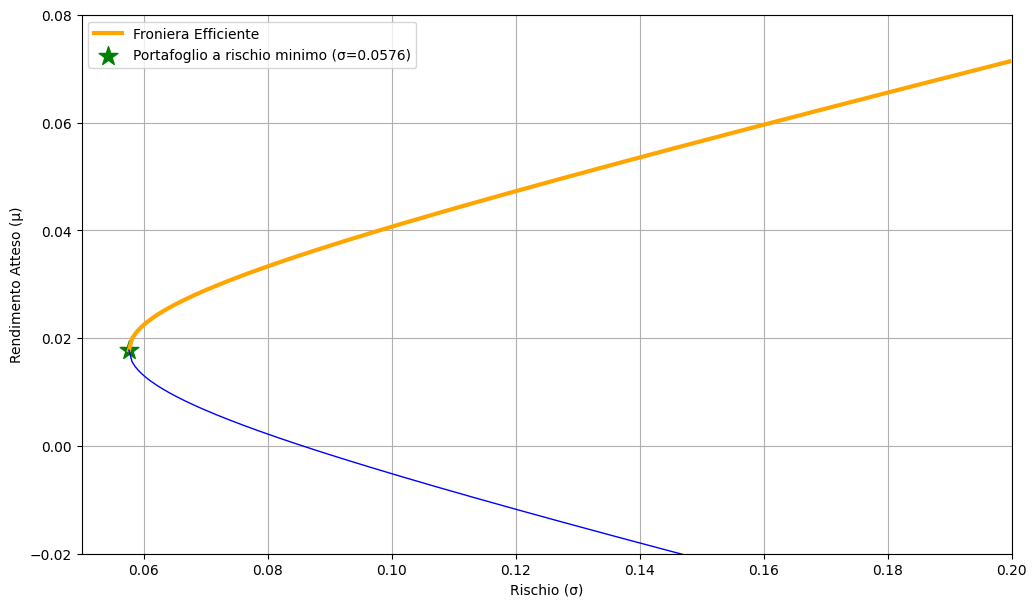

In [32]:
plt.figure(figsize=(12, 7))

plt.plot(sigma_valid, 
         mu_ef, 
         label='Froniera Efficiente', 
         color='orange', 
         linewidth=3)

plt.plot(sigma_valid, 
         mu_inf, 
         color='blue', 
         linewidth=1)

plt.scatter(sigma_min,
            mu_min,
            label=f'Portafoglio a rischio minimo (σ={sigma_min:.4f})', 
            marker='*',
            s=200,
            color='green')

plt.ylabel("Rendimento Atteso (µ)")
plt.xlabel("Rischio (σ)")
plt.legend()
plt.xlim(0.05,0.2)
plt.ylim(-0.02,0.08)
plt.grid(True)
plt.show()

In [19]:
rf = 0.02 / 12
sigma_tan_sqared = (1/a11)*(1+((a11*a22-a12**2)/((a12-rf*a11)**2)))
sigma_tan = np.sqrt(sigma_tan_sqared)
mu_tan = (a22-rf*a12)/(a12-rf*a11)

sr = (mu_tan-rf)/sigma_tan

print(sigma_tan)
print(mu_tan)

0.08167988639978634
0.033976093616173604


In [20]:
rf = 0.02 / 12
sigma_tan_sqared = (1/a11)*(1+((a11*a22-a12**2)/((a12-rf*a11)**2)))
sigma_tan = np.sqrt(sigma_tan_sqared)
mu_tan = (a22-rf*a12)/(a12-rf*a11)

sr = (mu_tan-rf)/sigma_tan

print(sigma_tan)
print(mu_tan)

0.08167988639978634
0.033976093616173604


In [21]:
sigma = np.arange(0, 0.2, 0.0005)
mu_cml = []

for i in sigma:
    mu = rf + sr * i
    mu_cml.append(mu)

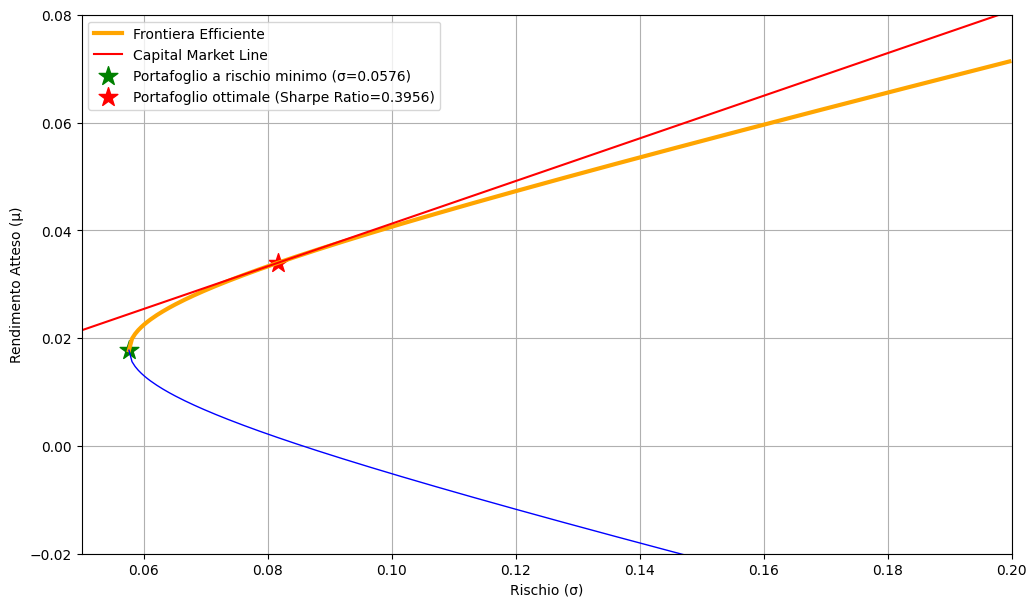

In [31]:
plt.figure(figsize=(12, 7))

plt.plot(sigma_valid, 
         mu_ef, 
         label='Frontiera Efficiente', 
         color='orange', 
         linewidth=3)

plt.plot(sigma_valid, 
         mu_inf, 
         color='blue', 
         linewidth=1)

plt.plot(sigma,
         mu_cml,
         label='Capital Market Line',
         color='red')

plt.scatter(sigma_min,
            mu_min,
            label=f'Portafoglio a rischio minimo (σ={sigma_min:.4f})',
            marker='*',
            s=200,
            color='green')

plt.scatter(sigma_tan,
            mu_tan,
            label=f'Portafoglio ottimale (Sharpe Ratio={sr:.4f})',
            marker='*',
            s=200,
            color='red')

plt.xlabel("Rischio (σ)")
plt.ylabel("Rendimento Atteso (µ)")
plt.legend()
plt.xlim(0.05,0.2)
plt.ylim(-0.02,0.08)
plt.grid(True)
plt.show()